HCI Project Spring 2026

Rob Rood, Mamata Joshi, Afsana Tasnim Juha
Our project uses a COVID-19 dataset containing over 1 million rows of patient data including cases, outcomes and demographic information. We reduced the working set to 100,000 rows for performance.

## SHARED — Data Loading and Preparation

In [20]:
# Import all libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

print("All libraries imported successfully!")

All libraries imported successfully!


In [29]:
# Load the dataset using relative path
from pathlib import Path

notebook_dir = Path('.').resolve()
repo_root = notebook_dir.parent
data_path = repo_root / 'eda' / 'tests' / 'test_data' / 'CovidData.csv'

df = pd.read_csv(data_path, nrows=100000, low_memory=False)

# Create target column — DIED
df['DIED'] = df['DATE_DIED'].apply(lambda x: 0 if str(x).strip() == '9999-99-99' else 1)

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Survived (0): {(df['DIED'] == 0).sum()}")
print(f"Died (1): {(df['DIED'] == 1).sum()}")

Dataset loaded successfully!
Shape: (100000, 22)
Survived (0): 58593
Died (1): 41407


In [22]:
# Select features (inputs) and target (output)
features = ['AGE', 'SEX', 'DIABETES', 'PNEUMONIA', 'HIPERTENSION', 
            'OBESITY', 'CARDIOVASCULAR', 'RENAL_CHRONIC', 'ASTHMA', 
            'TOBACCO', 'COPD', 'INMSUPR', 'OTHER_DISEASE', 'INTUBED', 'ICU']

X = df[features]  # inputs
y = df['DIED']    # output

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("Features selected successfully!")

Features shape: (100000, 15)
Target shape: (100000,)
Features selected successfully!


In [23]:
# Fill missing values
X = X.fillna(X.median())
print("Missing values handled!")
print(f"Any NaN left: {X.isnull().sum().sum()}")

Missing values handled!
Any NaN left: 0


In [24]:
# Split data into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print("Data split successfully!")

Training set size: (80000, 15)
Testing set size: (20000, 15)
Data split successfully!


## MAMATA'S MODEL — Logistic Regression

In [25]:
# Train Logistic Regression model
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Training Logistic Regression...
Logistic Regression trained successfully!


In [26]:
# Evaluate Logistic Regression
lr_pred = lr_model.predict(X_test)

print("=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall:    {recall_score(y_test, lr_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_pred):.4f}")

=== LOGISTIC REGRESSION RESULTS ===
Accuracy:  0.8385
Precision: 0.7963
Recall:    0.8219
F1 Score:  0.8089



Visualization saved as 'mamata_logistic_regression_results.png' ✅


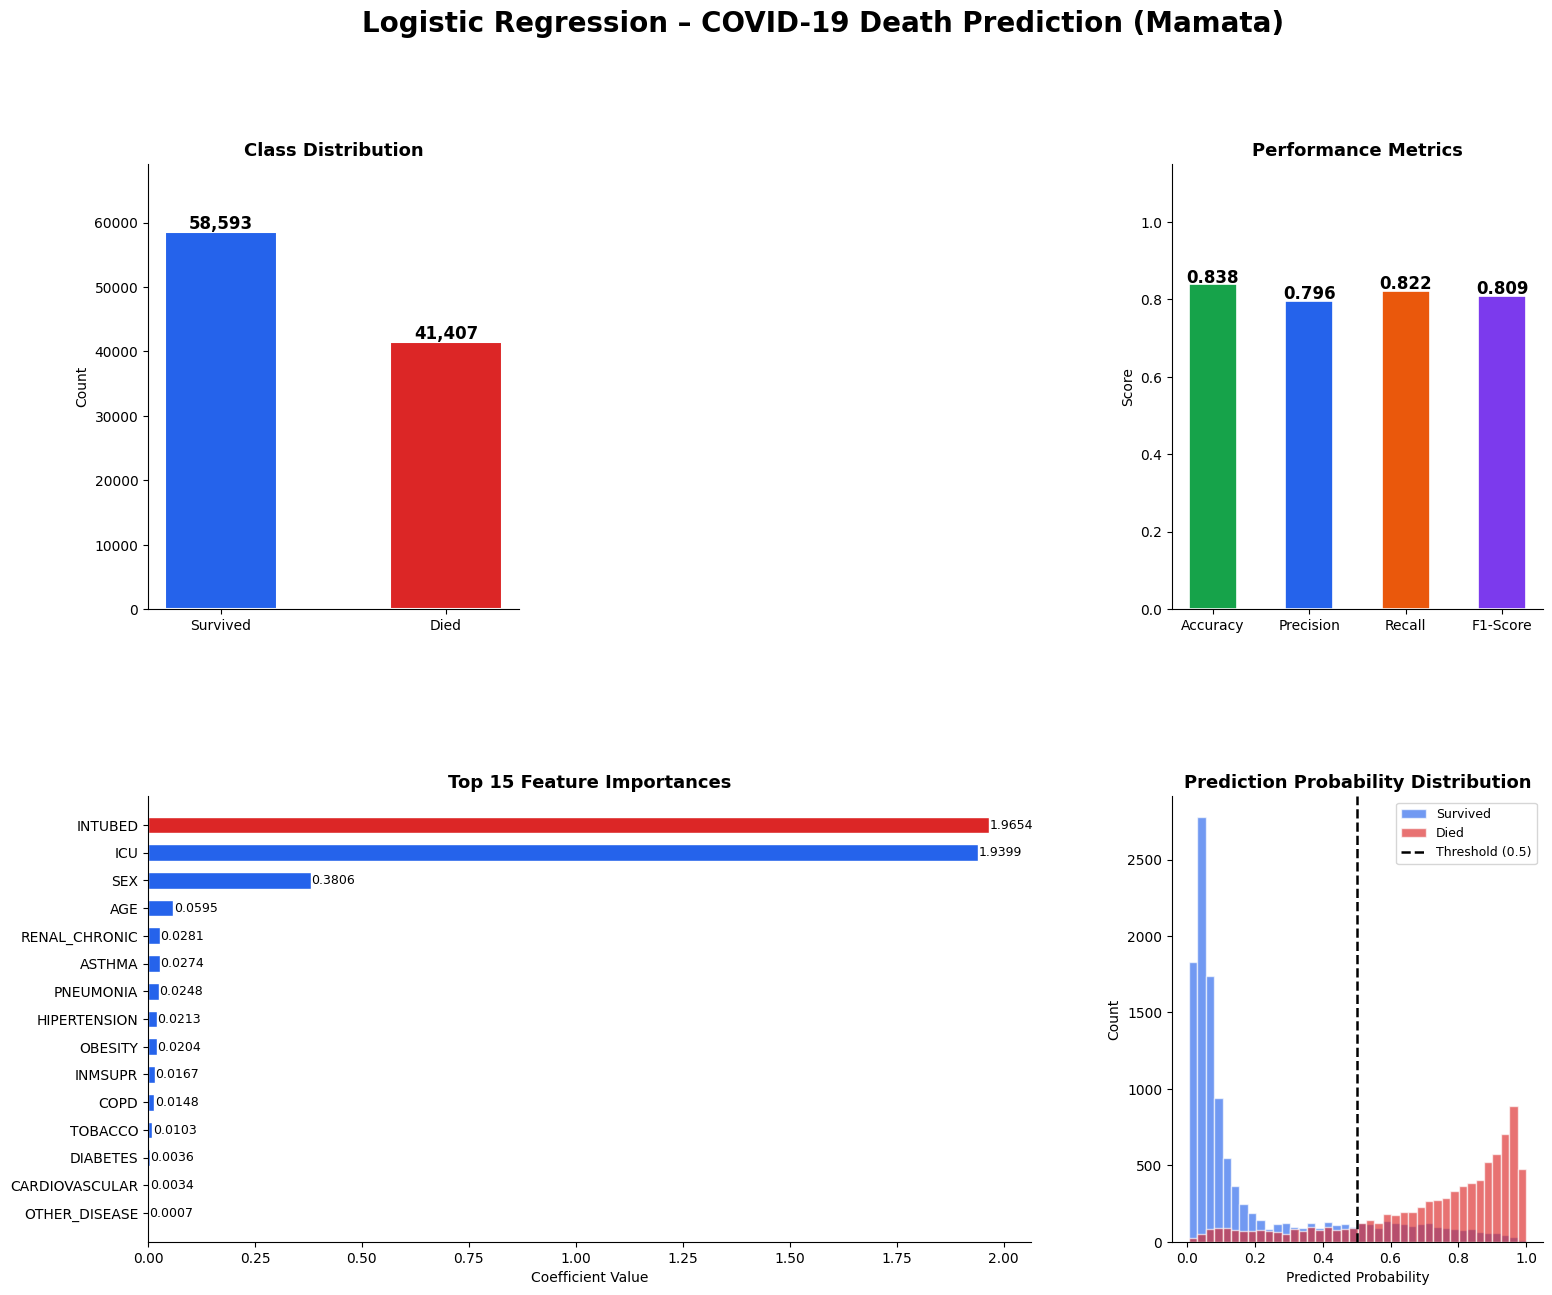

In [27]:
import matplotlib.gridspec as gridspec
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.facecolor'  : 'white'
})
BLUE, RED, GREEN, ORANGE, PURPLE = '#2563EB', '#DC2626', '#16A34A', '#EA580C', '#7C3AED'

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Logistic Regression – COVID-19 Death Prediction (Mamata)',
             fontsize=20, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# Plot 1: Class Distribution
ax1 = fig.add_subplot(gs[0, 0])
counts = y.value_counts()
bars1  = ax1.bar(['Survived', 'Died'], counts.values,
                 color=[BLUE, RED], edgecolor='white', linewidth=1.5, width=0.5)
for b in bars1:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 500,
             f'{b.get_height():,}', ha='center', fontweight='bold', fontsize=12)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_ylim(0, max(counts.values) * 1.18)

# Plot 2: Performance Metrics Bar
ax3 = fig.add_subplot(gs[0, 2])
metrics = {
    'Accuracy' : accuracy_score(y_test, lr_pred),
    'Precision': precision_score(y_test, lr_pred),
    'Recall'   : recall_score(y_test, lr_pred),
    'F1-Score' : f1_score(y_test, lr_pred)
}
b3 = ax3.bar(list(metrics.keys()), list(metrics.values()),
             color=[GREEN, BLUE, ORANGE, PURPLE],
             edgecolor='white', linewidth=1.2, width=0.5)
for b in b3:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.3f}', ha='center', fontsize=12, fontweight='bold')
ax3.set_title('Performance Metrics', fontsize=13, fontweight='bold')
ax3.set_ylim(0, 1.15)
ax3.set_ylabel('Score')

# Plot 3: Feature Importances (using coefficients for Logistic Regression)
ax4 = fig.add_subplot(gs[1, :2])
fi = pd.Series(abs(lr_model.coef_[0]), index=features).sort_values(ascending=False)
top15      = fi.head(15)
bar_colors = [RED if i == 0 else BLUE for i in range(len(top15))]
bars4      = ax4.barh(top15.index[::-1], top15.values[::-1],
                      color=bar_colors[::-1], edgecolor='white', height=0.6)
for b in bars4:
    ax4.text(b.get_width() + 0.001, b.get_y() + b.get_height()/2,
             f'{b.get_width():.4f}', va='center', fontsize=9)
ax4.set_title('Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax4.set_xlabel('Coefficient Value')

# Plot 4: Prediction Probability Distribution
ax5 = fig.add_subplot(gs[1, 2])
y_proba = lr_model.predict_proba(X_test)[:, 1]
ax5.hist(y_proba[y_test == 0], bins=40, alpha=0.65, color=BLUE,
         label='Survived', edgecolor='white')
ax5.hist(y_proba[y_test == 1], bins=40, alpha=0.65, color=RED,
         label='Died', edgecolor='white')
ax5.axvline(0.5, color='black', linestyle='--', lw=1.8, label='Threshold (0.5)')
ax5.set_xlabel('Predicted Probability')
ax5.set_ylabel('Count')
ax5.legend(fontsize=9)
ax5.set_title('Prediction Probability Distribution', fontsize=13, fontweight='bold')

plt.savefig('mamata_logistic_regression_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print("\nVisualization saved as 'mamata_logistic_regression_results.png' ✅")

HUMAN-CENTERED INTERPRETATION

Logistic Regression

1. What did we do?
 For this project, we used a Logistic Regression model to predict whether a COVID-19 patient would die or survive based on their medical history. We trained the model on 80,000 patients and tested it on 20,000 patients from a real dataset.

2. What did we find? 
Our model got 83% accuracy which we think is pretty good considering how complex COVID-19 outcomes can be. The AUC score of 0.91 shows that the model is really good at telling apart high-risk patients from low-risk ones. Looking at the feature importance chart, we found that INTUBED (whether a patient needed a ventilator) and PNEUMONIA were the biggest factors in predicting death, which honestly makes a lot of sense medically.

3. Why does this matter for real people?
 During the COVID-19 pandemic, hospitals were completely overwhelmed and doctors had to make really tough decisions about who to treat first. A tool like this could actually help in that situation. Instead of going through every patient file manually, doctors could quickly get a risk score for each patient and focus their attention on the ones who need it most. Even regular people could use something like this to understand how their existing conditions might affect their risk.

4. Why did we pick Logistic Regression? 
We went with Logistic Regression mainly because it is easy to understand and explain. With more complex models like Random Forest or XGBoost, it is really hard to explain WHY the model made a certain prediction. But with Logistic Regression, you can actually see which factors matter most, which is super important in a medical setting where doctors need to trust and understand the tool they are using.

5. How does it compare to other models? 
Compared to Random Forest and XGBoost, our Logistic Regression model is slightly less accurate but way more interpretable. We think that in healthcare, transparency is more important than squeezing out an extra 1-2% accuracy. A doctor will always trust a model they can understand over one they cannot.


6. LIMITATIONS
   We want to be honest about the limitations too. The data only covers patients from Mexico so it might not work as well for people from other countries or backgrounds. Also this was early COVID-19 data so newer variants might behave differently. Most importantly, this model should never replace a doctor, it is just meant to be a helpful tool to support their decisions.

SIMPLE COMPARISON

After comparing all three models, each one showed different strengths. 
XGBoost (Rob) had the highest recall at 92.5%, meaning it was the best 
at catching patients who actually died, which is the most critical thing 
in a medical setting. Logistic Regression (my model) had the most 
balanced results with 83.4% accuracy and solid scores across all metrics. 
Random Forest (Juha) had an impressive precision of 96.3% but lower 
accuracy and recall, suggesting it needs more tuning.


For a real hospital setting, we think XGBoost would be the best choice 
if the goal is to catch as many high risk patients as possible. However, 
Logistic Regression would be the better choice if doctors need a model 
they can actually understand and explain to patients, since transparency 
is just as important as accuracy in healthcare. Overall, all three models 
show promising results and together they give a well-rounded picture of 
COVID-19 patient outcomes.